# **1. What is Supervised Learning?**

**Supervised Learning** is a type of Machine Learning in which the model learns from examples that already contain the correct answer.

Each observation contains:

- **Features ($X$):** the input variables used to make a prediction.
- **Target ($y$):** the variable that we want to predict.

The model learns a relationship of the form:

$$
X \longrightarrow y
$$

For example:

| Age | Income | Previous Purchases | Will Buy |
|---:|---:|---:|---|
| 20 | 500 | 2 | No |
| 35 | 1500 | 8 | Yes |
| 50 | 3000 | 15 | Yes |

Here:

- `Age`, `Income`, and `Previous Purchases` are **features**.
- `Will Buy` is the **target**.

The algorithm learns from known examples and then tries to predict the target for new observations.


## **1.1 Classification vs Regression**

There are two main types of supervised learning problems.

### **Classification**

The target is a **category or class**.

### **Regression**

The target is a **numerical value**.
This notebook automatically decides whether the problem looks like classification or regression after you define the target column.


## **2. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


# **2. Load the Dataset**

In [3]:


file_path = r"C:\Documentos\2SEM2026\intelligence Artificial\lab assigment 1\mdi_personasdesaparecidas_pm_2026_enero_julio.xlsx"



In [4]:
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")

for i, sheet in enumerate(excel_file.sheet_names):
    print(i, "->", sheet)


Available sheets:
0 -> Contenido
1 -> 1. Pdesaparecidas


In [5]:
sheet_name = None

for sheet in excel_file.sheet_names:
    if "pdesaparecidas" in sheet.lower():
        sheet_name = sheet
        break

if sheet_name is None:
    if len(excel_file.sheet_names) > 1:
        sheet_name = excel_file.sheet_names[1]
    else:
        sheet_name = excel_file.sheet_names[0]

print("Selected sheet:", sheet_name)

data = pd.read_excel(
    file_path,
    sheet_name=sheet_name
)

print("File read successfully.")


Selected sheet: 1. Pdesaparecidas
File read successfully.


In [6]:
print(data["situacion_actual"].value_counts())

print(
    data["situacion_actual"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

situacion_actual
ENCONTRADO      3528
DESAPARECIDO     742
FALLECIDO        237
Name: count, dtype: int64
situacion_actual
ENCONTRADO      78.28
DESAPARECIDO    16.46
FALLECIDO        5.26
Name: proportion, dtype: float64


# **3. Initial Dataset Exploration**

Before building a model, we should understand the structure of the dataset.


In [7]:
print("Dataset dimensions:", data.shape)

print("\nFirst 10 rows:")
display(data.head(10))


Dataset dimensions: (4507, 26)

First 10 rows:


,fecha_desaparicion,fecha_denuncia,fecha_conocimiento,zona,distrito,circuito,subcircuito,codigo_provincia,provincia,codigo_canton,...,rango_edad,etnia,fecha_localizacion,latitud_localizacion,longitud_localizacion,provincia_localizacion,situacion_actual,motivacion,motivacion_observada,status
0,2026-07-31,2026-08-03,2026-08-03,ZONA 7,MACHALA,PÁEZ,PÁEZ 1,7,EL ORO,701,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
1,2026-07-31,2026-08-01,2026-08-04,ZONA 8,9 DE OCTUBRE,CHILE,CHILE 4,9,GUAYAS,901,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
2,2026-07-31,2026-08-03,2026-08-03,ZONA 2,RUMIÑAHUI - MEJÍA,FAJARDO,FAJARDO 2,17,PICHINCHA,1705,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
3,2026-07-31,2026-07-31,2026-08-04,ZONA 8,ESTEROS,ESTEROS,ESTEROS 2,9,GUAYAS,901,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
4,2026-07-31,2026-07-31,2026-07-31,ZONA 9,EUGENIO ESPEJO,SAN ISIDRO DEL INCA,SAN ISIDRO DEL INCA 4,17,PICHINCHA,1701,...,ADOLESCENTES,MESTIZO/A,2026/08/01,"-0,193758000000000014","-78,4663079999999979",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA
5,2026-07-31,2026-08-01,2026-08-01,ZONA 9,MANUELA SÁENZ,MONJAS COLLACOTO,MONJAS COLLACOTO 2,17,PICHINCHA,1701,...,ADULTO,MESTIZO/A,2026/08/01,"0,238295487490065183","-78,4834260055501147",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA
6,2026-07-31,2026-07-31,2026-07-31,ZONA 9,MANUELA SÁENZ,MONJAS COLLACOTO,MONJAS COLLACOTO 2,17,PICHINCHA,1701,...,ADULTO MAYOR,MESTIZO/A,2026/08/03,"-1,46866500000000011","-77,9921599999999984",PASTAZA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA
7,2026-07-31,2026-08-02,2026-08-03,ZONA 8,PASCUALES,BASTIÓN POPULAR SUR,BASTIÓN POPULAR SUR 1,9,GUAYAS,901,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
8,2026-07-31,2026-08-01,2026-08-01,ZONA 9,EUGENIO ESPEJO,EL BOSQUE,EL BOSQUE 5,17,PICHINCHA,1701,...,ADULTO,MESTIZO/A,2026/08/01,"-0,192689500000000014","-78,5134398999999945",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA
9,2026-07-31,2026-08-07,2026-08-07,ZONA 9,CALDERÓN,CARAPUNGO,CARAPUNGO 3,17,PICHINCHA,1701,...,ADULTO MAYOR,MESTIZO/A,2026/08/10,"-0,253989901556538278","-79,1761479261778192",SANTO DOMINGO DE LOS TSACHILAS,ENCONTRADO,EXTRAVIADO - AUSENCIA TEMPORAL,ACCIDENTAL POR DESCUIDO,EXTRAVÍO


In [8]:
print("Dataset information:")
data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4507 entries, 0 to 4506
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha_desaparicion      4507 non-null   datetime64[ns]
 1   fecha_denuncia          4507 non-null   datetime64[ns]
 2   fecha_conocimiento      4507 non-null   datetime64[ns]
 3   zona                    4507 non-null   object        
 4   distrito                4507 non-null   object        
 5   circuito                4507 non-null   object        
 6   subcircuito             4507 non-null   object        
 7   codigo_provincia        4507 non-null   int64         
 8   provincia               4507 non-null   object        
 9   codigo_canton           4507 non-null   int64         
 10  canton                  4507 non-null   object        
 11  latitud                 4507 non-null   object        
 12  longitud                450

In [9]:
print("Column names:")

for column in data.columns:
    print("-", column)


Column names:
- fecha_desaparicion
- fecha_denuncia
- fecha_conocimiento
- zona
- distrito
- circuito
- subcircuito
- codigo_provincia
- provincia
- codigo_canton
- canton
- latitud
- longitud
- sexo
- nacionalidad
- edad
- rango_edad
- etnia
- fecha_localizacion
- latitud_localizacion
- longitud_localizacion
- provincia_localizacion
- situacion_actual
- motivacion
- motivacion_observada
- status


In [10]:
print("Missing values per column:")
display(
    data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)


Missing values per column:


,Missing Values
fecha_desaparicion,0
fecha_denuncia,0
fecha_conocimiento,0
zona,0
distrito,0
circuito,0
subcircuito,0
codigo_provincia,0
provincia,0
codigo_canton,0


# **4. Clean the Dataset**

We remove:

- Completely empty rows.
- Completely empty columns.
- Columns whose names start with `Unnamed`.
- Extra spaces in column names.


In [11]:
clean_data = data.copy()

clean_data = clean_data.dropna(
    axis=0,
    how="all"
)

clean_data = clean_data.dropna(
    axis=1,
    how="all"
)

clean_data.columns = [
    str(column).strip()
    for column in clean_data.columns
]

unnamed_columns = [
    column
    for column in clean_data.columns
    if column.lower().startswith("unnamed")
]

clean_data = clean_data.drop(
    columns=unnamed_columns,
    errors="ignore"
)

clean_data = clean_data.reset_index(drop=True)

print("Dimensions after cleaning:", clean_data.shape)
display(clean_data.head())


Dimensions after cleaning: (4507, 26)


,fecha_desaparicion,fecha_denuncia,fecha_conocimiento,zona,distrito,circuito,subcircuito,codigo_provincia,provincia,codigo_canton,...,rango_edad,etnia,fecha_localizacion,latitud_localizacion,longitud_localizacion,provincia_localizacion,situacion_actual,motivacion,motivacion_observada,status
0,2026-07-31,2026-08-03,2026-08-03,ZONA 7,MACHALA,PÁEZ,PÁEZ 1,7,EL ORO,701,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
1,2026-07-31,2026-08-01,2026-08-04,ZONA 8,9 DE OCTUBRE,CHILE,CHILE 4,9,GUAYAS,901,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
2,2026-07-31,2026-08-03,2026-08-03,ZONA 2,RUMIÑAHUI - MEJÍA,FAJARDO,FAJARDO 2,17,PICHINCHA,1705,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
3,2026-07-31,2026-07-31,2026-08-04,ZONA 8,ESTEROS,ESTEROS,ESTEROS 2,9,GUAYAS,901,...,ADULTO,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN
4,2026-07-31,2026-07-31,2026-07-31,ZONA 9,EUGENIO ESPEJO,SAN ISIDRO DEL INCA,SAN ISIDRO DEL INCA 4,17,PICHINCHA,1701,...,ADOLESCENTES,MESTIZO/A,2026/08/01,"-0,193758000000000014","-78,4663079999999979",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA


## **5 Try to Convert Numerical Values Stored as Text**

Sometimes Excel imports numerical columns as text. The following block tries to convert a column when at least 80% of its valid values can be interpreted as numbers.


In [12]:
for column in clean_data.columns:

    if clean_data[column].dtype == "object":

        converted = pd.to_numeric(
            clean_data[column],
            errors="coerce"
        )

        original_valid = clean_data[column].notna().sum()
        converted_valid = converted.notna().sum()

        if original_valid > 0:

            ratio = converted_valid / original_valid

            if ratio >= 0.80:
                clean_data[column] = converted

print("Conversion completed.")


Conversion completed.


# **6. Define the Target Variable**

This is the most important difference between supervised and unsupervised learning.

In supervised learning, we must specify the column that contains the answer we want to predict.


In [13]:
target_column = "situacion_actual"

if target_column not in clean_data.columns:

    print("Available columns:")

    for column in clean_data.columns:
        print("-", column)

    raise ValueError(
        f"The target column '{target_column}' was not found."
    )


print("Target variable:", target_column)


print("\nTarget values:")

print(
    clean_data[
        target_column
    ].value_counts(
        dropna=False
    )
)

Target variable: situacion_actual

Target values:
situacion_actual
ENCONTRADO      3528
DESAPARECIDO     742
FALLECIDO        237
Name: count, dtype: int64


# **7. Remove Rows with Missing Target Values**

A supervised learning model cannot train on observations whose correct target value is unknown.


In [14]:
before = len(clean_data)

clean_data = clean_data.dropna(
    subset=[target_column]
).reset_index(drop=True)

after = len(clean_data)

print("Rows before:", before)
print("Rows after:", after)
print(
    "Rows removed because the target was missing:",
    before - after
)


Rows before: 4507
Rows after: 4507
Rows removed because the target was missing: 0




## 9. Select Predictor Variables and Prevent Data Leakage

Not every variable should be used to predict the target.

Some variables contain information that becomes available after the person has been located and could directly reveal the target value. Using these variables would cause data leakage.

Other variables are identifiers, redundant variables, or numerical codes without quantitative meaning.

These variables will therefore be excluded from the model.

In [15]:
columns_to_exclude = [
    # Target
    "situacion_actual",

    # Information available after localization
    "fecha_localizacion",
    "latitud_localizacion",
    "longitud_localizacion",
    "provincia_localizacion",

    # Possible target leakage
    "status",

    # Administrative codes
    "codigo_provincia",
    "codigo_canton",

    # Redundant with edad
    "rango_edad"
]

print("Columns excluded from the model:")

for column in columns_to_exclude:

    if column in clean_data.columns:
        print("-", column)

Columns excluded from the model:
- situacion_actual
- fecha_localizacion
- latitud_localizacion
- longitud_localizacion
- provincia_localizacion
- status
- codigo_provincia
- codigo_canton
- rango_edad


## 10. Define Features and Target

The dataset is now divided into:

- `X`: predictor variables used by the model.
- `y`: target variable that the model will learn to predict.

In [16]:
X = clean_data.drop(
    columns=columns_to_exclude,
    errors="ignore"
)

y = clean_data[target_column]

print("Predictor dimensions:", X.shape)
print("Target dimensions:", y.shape)

print("\nPredictor variables:")

for column in X.columns:
    print("-", column)

Predictor dimensions: (4507, 17)
Target dimensions: (4507,)

Predictor variables:
- fecha_desaparicion
- fecha_denuncia
- fecha_conocimiento
- zona
- distrito
- circuito
- subcircuito
- provincia
- canton
- latitud
- longitud
- sexo
- nacionalidad
- edad
- etnia
- motivacion
- motivacion_observada


## 11. Train-Test Split

The dataset is divided into training and testing subsets.

- 80% of the data will be used to train the models.
- 20% will be used to evaluate their performance on unseen data.

Because the target classes are imbalanced, stratified sampling is used to preserve approximately the same class proportions in both subsets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 3605
Testing observations: 902


In [18]:
print("Training target distribution:")

print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")

print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training target distribution:
situacion_actual
ENCONTRADO      78.28
DESAPARECIDO    16.45
FALLECIDO        5.27
Name: proportion, dtype: float64

Testing target distribution:
situacion_actual
ENCONTRADO      78.27
DESAPARECIDO    16.52
FALLECIDO        5.21
Name: proportion, dtype: float64


# **13. Identify Numerical and Categorical Features**

In [19]:
X_train = X_train.copy()
X_test = X_test.copy()

date_columns = [
    "fecha_desaparicion",
    "fecha_denuncia",
    "fecha_conocimiento"
]

for dataset in [X_train, X_test]:

    for column in date_columns:

        if column in dataset.columns:

            dataset[column] = pd.to_datetime(
                dataset[column],
                errors="coerce"
            )


    if "fecha_desaparicion" in dataset.columns:

        dataset["mes_desaparicion"] = (
            dataset["fecha_desaparicion"].dt.month
        )

        dataset["dia_semana_desaparicion"] = (
            dataset["fecha_desaparicion"].dt.dayofweek
        )


    if (
        "fecha_desaparicion" in dataset.columns
        and "fecha_denuncia" in dataset.columns
    ):

        dataset["dias_hasta_denuncia"] = (
            dataset["fecha_denuncia"]
            - dataset["fecha_desaparicion"]
        ).dt.days


    if (
        "fecha_desaparicion" in dataset.columns
        and "fecha_conocimiento" in dataset.columns
    ):

        dataset["dias_hasta_conocimiento"] = (
            dataset["fecha_conocimiento"]
            - dataset["fecha_desaparicion"]
        ).dt.days


X_train = X_train.drop(
    columns=date_columns,
    errors="ignore"
)

X_test = X_test.drop(
    columns=date_columns,
    errors="ignore"
)

print("Date feature engineering completed.")

print("\nTraining dimensions:")
print(X_train.shape)

print("\nTesting dimensions:")
print(X_test.shape)

Date feature engineering completed.

Training dimensions:
(3605, 18)

Testing dimensions:
(902, 18)


In [20]:
coordinate_columns = [
    "latitud",
    "longitud"
]

for column in coordinate_columns:

    if column in X_train.columns:

        X_train[column] = (
            X_train[column]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )

        X_train[column] = pd.to_numeric(
            X_train[column],
            errors="coerce"
        )


    if column in X_test.columns:

        X_test[column] = (
            X_test[column]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )

        X_test[column] = pd.to_numeric(
            X_test[column],
            errors="coerce"
        )

print("Coordinate conversion completed.")

Coordinate conversion completed.


In [21]:
high_cardinality_columns = [
    "distrito",
    "circuito",
    "subcircuito", "motivacion","motivacion_observada"
]

X_train = X_train.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)

X_test = X_test.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)

print("Removed high-cardinality variables:")

for column in high_cardinality_columns:
    print("-", column)

Removed high-cardinality variables:
- distrito
- circuito
- subcircuito
- motivacion
- motivacion_observada


In [22]:
numerical_columns = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical variables:")

for column in numerical_columns:
    print("-", column)

print("\nCategorical variables:")

for column in categorical_columns:
    print("-", column)

Numerical variables:
- latitud
- longitud
- edad
- mes_desaparicion
- dia_semana_desaparicion
- dias_hasta_denuncia
- dias_hasta_conocimiento

Categorical variables:
- zona
- provincia
- canton
- sexo
- nacionalidad
- etnia


In [23]:
print("Number of unique values:")

for column in categorical_columns:

    print(
        column,
        "->",
        X_train[column].nunique()
    )

Number of unique values:
zona -> 9
provincia -> 24
canton -> 175
sexo -> 2
nacionalidad -> 7
etnia -> 9


## 14. Preprocessing

Numerical and categorical variables require different preprocessing procedures.

### Numerical Variables

1. Missing values are replaced with the median.
2. StandardScaler is applied so that numerical variables have comparable scales.

### Categorical Variables

1. Missing values are replaced with the most frequent category.
2. OneHotEncoder converts categorical variables into numerical representations.

The preprocessing parameters will be learned only from the training data.

In [24]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 15. Logistic Regression

Logistic Regression will be used as the first classification model.

Although the name contains the word "regression", Logistic Regression is a classification algorithm.

Because the target variable is imbalanced, `class_weight="balanced"` is used so that minority classes receive more importance during training.

In [25]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.




The model is trained exclusively using the training dataset.

The test dataset remains unseen during training and will be used later to evaluate the model.

In [26]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


# **16. Train Supervised Learning Models**

We will compare two models.

### If the problem is Classification

- Logistic Regression
- Random Forest Classifier

### If the problem is Regression

- Linear Regression
- Random Forest Regressor


In [27]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [28]:
logistic_predictions = logistic_model.predict(
    X_test
)

print("Predictions completed.")

print("\nFirst 20 predictions:")

print(
    logistic_predictions[:20]
)

Predictions completed.

First 20 predictions:
['ENCONTRADO' 'FALLECIDO' 'ENCONTRADO' 'ENCONTRADO' 'DESAPARECIDO'
 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'DESAPARECIDO' 'DESAPARECIDO'
 'DESAPARECIDO' 'DESAPARECIDO' 'ENCONTRADO' 'DESAPARECIDO' 'ENCONTRADO'
 'DESAPARECIDO' 'ENCONTRADO' 'DESAPARECIDO' 'ENCONTRADO' 'DESAPARECIDO']


## 17. Logistic Regression Evaluation

The classification model is evaluated using several metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report

Because the target variable is imbalanced, the Macro F1-score is particularly important because it gives equal importance to all classes.

In [29]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

print("Logistic Regression Results")
print("-" * 45)

print(
    f"Accuracy:  {logistic_accuracy:.4f}"
)

print(
    f"Precision: {logistic_precision:.4f}"
)

print(
    f"Recall:    {logistic_recall:.4f}"
)

print(
    f"F1-score:  {logistic_f1:.4f}"
)
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Results
---------------------------------------------
Accuracy:  0.5499
Precision: 0.4440
Recall:    0.5532
F1-score:  0.4248
              precision    recall  f1-score   support

DESAPARECIDO       0.30      0.48      0.37       149
  ENCONTRADO       0.90      0.56      0.69       706
   FALLECIDO       0.13      0.62      0.21        47

    accuracy                           0.55       902
   macro avg       0.44      0.55      0.42       902
weighted avg       0.76      0.55      0.61       902





### Confusion Matrix

The confusion matrix shows how many observations were correctly and incorrectly classified for each target category.

In [30]:
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

labels = logistic_model.classes_

print("Classes:")
print(labels)

print("\nConfusion Matrix:")
print(logistic_confusion_matrix)

Classes:
['DESAPARECIDO' 'ENCONTRADO' 'FALLECIDO']

Confusion Matrix:
[[ 72  35  42]
 [158 395 153]
 [ 11   7  29]]


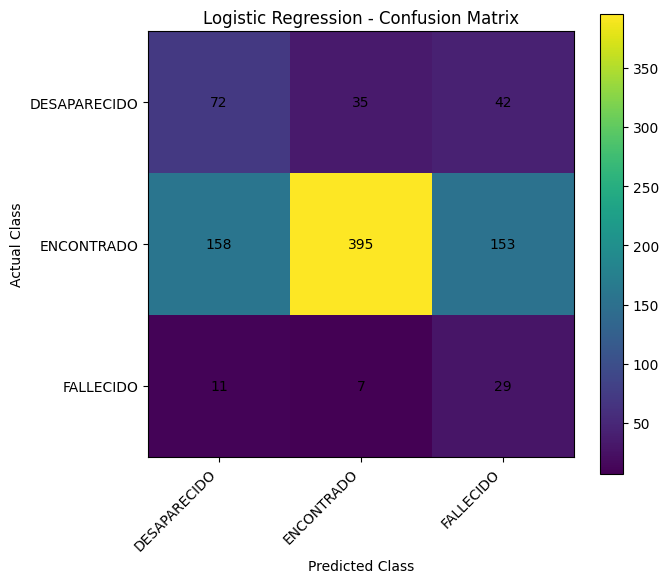

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    logistic_confusion_matrix
)

ax.set_title(
    "Logistic Regression - Confusion Matrix"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    labels
)

for i in range(len(labels)):

    for j in range(len(labels)):

        ax.text(
            j,
            i,
            logistic_confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.show()

## 20. Random Forest

Random Forest is an ensemble classification algorithm composed of multiple decision trees.

It can capture more complex and nonlinear relationships than Logistic Regression.

`class_weight="balanced"` is used because the target classes are imbalanced.

In [32]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [33]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [34]:
random_forest_predictions = random_forest_model.predict(
    X_test
)

print("Predictions completed.")

print("\nFirst 20 predictions:")

print(
    random_forest_predictions[:20]
)

Predictions completed.

First 20 predictions:
['ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'DESAPARECIDO'
 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO'
 'ENCONTRADO' 'DESAPARECIDO' 'ENCONTRADO' 'DESAPARECIDO' 'ENCONTRADO'
 'DESAPARECIDO' 'ENCONTRADO' 'ENCONTRADO' 'ENCONTRADO' 'DESAPARECIDO']


In [35]:
rf_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

rf_precision = precision_score(
    y_test,
    random_forest_predictions,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    random_forest_predictions,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    random_forest_predictions,
    average="macro",
    zero_division=0
)


print("Random Forest Results")
print("-" * 45)

print(
    f"Accuracy:  {rf_accuracy:.4f}"
)

print(
    f"Precision: {rf_precision:.4f}"
)

print(
    f"Recall:    {rf_recall:.4f}"
)

print(
    f"F1-score:  {rf_f1:.4f}"
)
print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest Results
---------------------------------------------
Accuracy:  0.7661
Precision: 0.5580
Recall:    0.5041
F1-score:  0.5175
              precision    recall  f1-score   support

DESAPARECIDO       0.40      0.45      0.43       149
  ENCONTRADO       0.86      0.87      0.87       706
   FALLECIDO       0.41      0.19      0.26        47

    accuracy                           0.77       902
   macro avg       0.56      0.50      0.52       902
weighted avg       0.76      0.77      0.76       902




### Confusion Matrix

The confusion matrix shows how many observations were correctly and incorrectly classified for each target category.

In [36]:
rf_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

labels = random_forest_model.classes_

print("Classes:")
print(labels)

print("\nConfusion Matrix:")
print(rf_confusion_matrix)

Classes:
['DESAPARECIDO' 'ENCONTRADO' 'FALLECIDO']

Confusion Matrix:
[[ 67  77   5]
 [ 83 615   8]
 [ 16  22   9]]


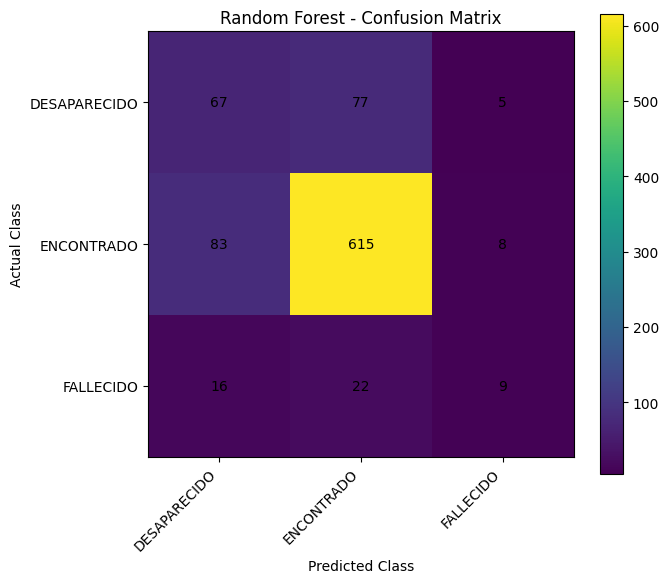

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    rf_confusion_matrix
)

ax.set_title(
    "Random Forest - Confusion Matrix"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    labels
)

for i in range(len(labels)):

    for j in range(len(labels)):

        ax.text(
            j,
            i,
            rf_confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.show()

## 21. Model Comparison

The performance of Logistic Regression and Random Forest is compared using Accuracy, Macro Precision, Macro Recall, and Macro F1-score.

Because the dataset is imbalanced, Macro F1-score is one of the most important metrics for selecting the final model.

In [38]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],

        "Accuracy": [
            logistic_accuracy,
            rf_accuracy
        ],

        "Macro Precision": [
            logistic_precision,
            rf_precision
        ],

        "Macro Recall": [
            logistic_recall,
            rf_recall
        ],

        "Macro F1": [
            logistic_f1,
            rf_f1
        ]
    }
)

model_comparison = model_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    model_comparison.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.7661,0.558,0.5041,0.5175
1,Logistic Regression,0.5499,0.444,0.5532,0.4248


In [39]:
best_model_name = model_comparison.loc[
    0,
    "Model"
]

best_macro_f1 = model_comparison.loc[
    0,
    "Macro F1"
]

print("Best model:", best_model_name)

print(
    "Best Macro F1-score:",
    round(best_macro_f1, 4)
)

Best model: Random Forest
Best Macro F1-score: 0.5175


In [40]:
print("Predictor variables:")

for column in X_train.columns:
    print("-", column)

print(
    "\nTarget inside X_train:",
    target_column in X_train.columns
)

Predictor variables:
- zona
- provincia
- canton
- latitud
- longitud
- sexo
- nacionalidad
- edad
- etnia
- mes_desaparicion
- dia_semana_desaparicion
- dias_hasta_denuncia
- dias_hasta_conocimiento

Target inside X_train: False


In [41]:
print("Random Forest Classification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

DESAPARECIDO       0.40      0.45      0.43       149
  ENCONTRADO       0.86      0.87      0.87       706
   FALLECIDO       0.41      0.19      0.26        47

    accuracy                           0.77       902
   macro avg       0.56      0.50      0.52       902
weighted avg       0.76      0.77      0.76       902



## 22. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

The diagonal represents correct predictions, while values outside the diagonal represent classification errors.

In [42]:
rf_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

labels = random_forest_model.classes_

print("Classes:")
print(labels)

print("\nConfusion Matrix:")
print(rf_confusion_matrix)

Classes:
['DESAPARECIDO' 'ENCONTRADO' 'FALLECIDO']

Confusion Matrix:
[[ 67  77   5]
 [ 83 615   8]
 [ 16  22   9]]


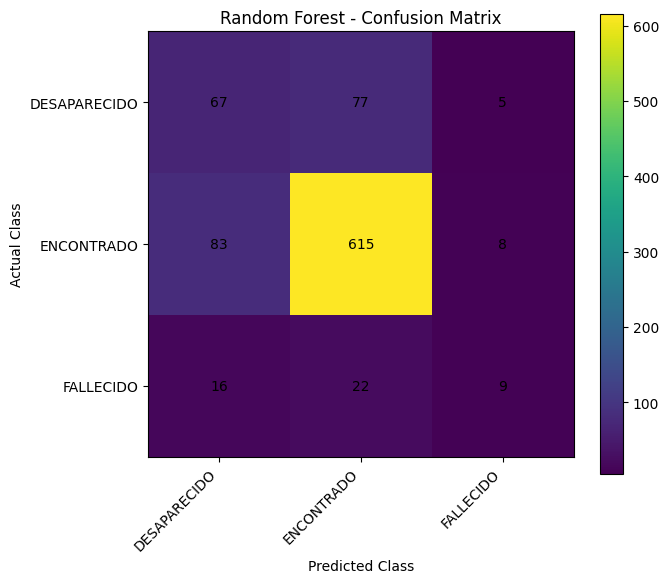

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(rf_confusion_matrix)

ax.set_title(
    "Random Forest - Confusion Matrix"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(labels)

for i in range(len(labels)):

    for j in range(len(labels)):

        ax.text(
            j,
            i,
            rf_confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.show()

In [44]:
print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

DESAPARECIDO       0.40      0.45      0.43       149
  ENCONTRADO       0.86      0.87      0.87       706
   FALLECIDO       0.41      0.19      0.26        47

    accuracy                           0.77       902
   macro avg       0.56      0.50      0.52       902
weighted avg       0.76      0.77      0.76       902



In [45]:
print(
    confusion_matrix(
        y_test,
        random_forest_predictions
    )
)

[[ 67  77   5]
 [ 83 615   8]
 [ 16  22   9]]


## 24. k-Nearest Neighbors (kNN)

The k-Nearest Neighbors algorithm classifies an observation according to the classes of its nearest neighbors.

The parameter `k` represents the number of neighbors considered by the model.

Unlike K-Means, where `k` represented the number of clusters, in kNN:

\[
k = \text{number of nearest neighbors}
\]

Different values of `k` will be evaluated using cross-validation on the training set.

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            KNeighborsClassifier()
        )
    ]
)

print("kNN pipeline created successfully.")


kNN pipeline created successfully.


## 25. Search for the Optimal Value of k

Several values of `k` are evaluated using stratified 5-fold cross-validation.

Because the dataset is imbalanced, Macro F1-score is used as the main metric for selecting the optimal value of `k`.

Stratified cross-validation preserves approximately the same class proportions in each fold.

In [48]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parameter_grid = {
    "classifier__n_neighbors": list(range(1, 31))
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=False
)

knn_search.fit(
    X_train,
    y_train
)

print("Search completed.")

print(
    "Best value of k:",
    knn_search.best_params_["classifier__n_neighbors"]
)

print(
    "Best cross-validation Macro F1:",
    round(knn_search.best_score_, 4)
)

Search completed.
Best value of k: 1
Best cross-validation Macro F1: 0.4698


In [49]:
knn_results = pd.DataFrame(
    {
        "k": knn_search.cv_results_[
            "param_classifier__n_neighbors"
        ].astype(int),

        "Mean Macro F1": knn_search.cv_results_[
            "mean_test_score"
        ],

        "Standard Deviation": knn_search.cv_results_[
            "std_test_score"
        ]
    }
)

display(
    knn_results.round(4)
)

,k,Mean Macro F1,Standard Deviation
0,1,0.4698,0.0216
1,2,0.4493,0.0265
2,3,0.4600,0.0200
3,4,0.4653,0.0174
4,5,0.4335,0.0091
5,6,0.4529,0.0198
6,7,0.4324,0.0155
7,8,0.4287,0.0142
8,9,0.4207,0.0106
9,10,0.4150,0.0099


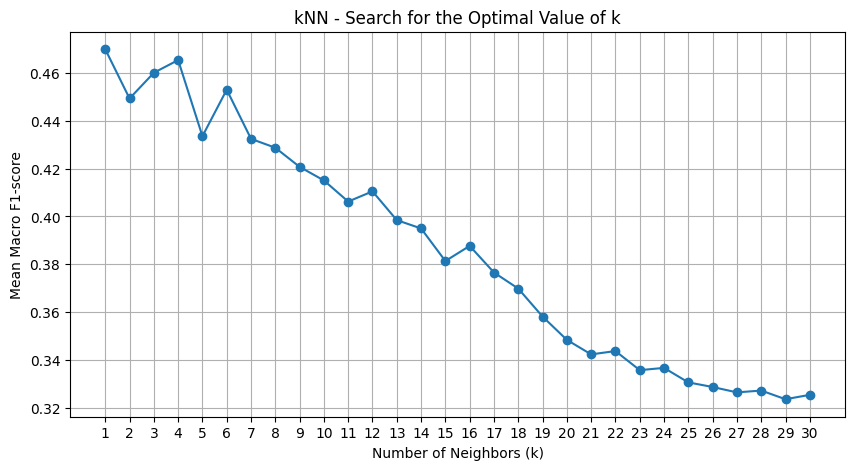

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(
    knn_results["k"],
    knn_results["Mean Macro F1"],
    marker="o"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Macro F1-score")
plt.title("kNN - Search for the Optimal Value of k")

plt.xticks(
    knn_results["k"]
)

plt.grid()

plt.show()

In [53]:
best_k = knn_search.best_params_[
    "classifier__n_neighbors"
]

best_knn_model = knn_search.best_estimator_

print("Optimal k:", best_k)

print(
    "Cross-validation Macro F1:",
    round(knn_search.best_score_, 4)
)

Optimal k: 1
Cross-validation Macro F1: 0.4698


## 26. Evaluation of the Optimal kNN Model

After selecting the optimal value of `k` using only the training data, the final kNN model is evaluated on the test set.

Accuracy, Macro Precision, Macro Recall, and Macro F1-score are calculated.

In [54]:
knn_predictions = best_knn_model.predict(
    X_test
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_precision = precision_score(
    y_test,
    knn_predictions,
    average="macro",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_predictions,
    average="macro",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_predictions,
    average="macro",
    zero_division=0
)

print("Optimal kNN Results")
print("-" * 45)

print("Optimal k:", best_k)
print(f"Accuracy:        {knn_accuracy:.4f}")
print(f"Macro Precision: {knn_precision:.4f}")
print(f"Macro Recall:    {knn_recall:.4f}")
print(f"Macro F1:        {knn_f1:.4f}")

Optimal kNN Results
---------------------------------------------
Optimal k: 1
Accuracy:        0.7273
Macro Precision: 0.4713
Macro Recall:    0.4637
Macro F1:        0.4673


In [55]:
knn_confusion_matrix = confusion_matrix(
    y_test,
    knn_predictions
)

knn_labels = best_knn_model.classes_

print("Classes:")
print(knn_labels)

print("\nConfusion Matrix:")
print(knn_confusion_matrix)

Classes:
['DESAPARECIDO' 'ENCONTRADO' 'FALLECIDO']

Confusion Matrix:
[[ 46  95   8]
 [ 82 599  25]
 [ 11  25  11]]


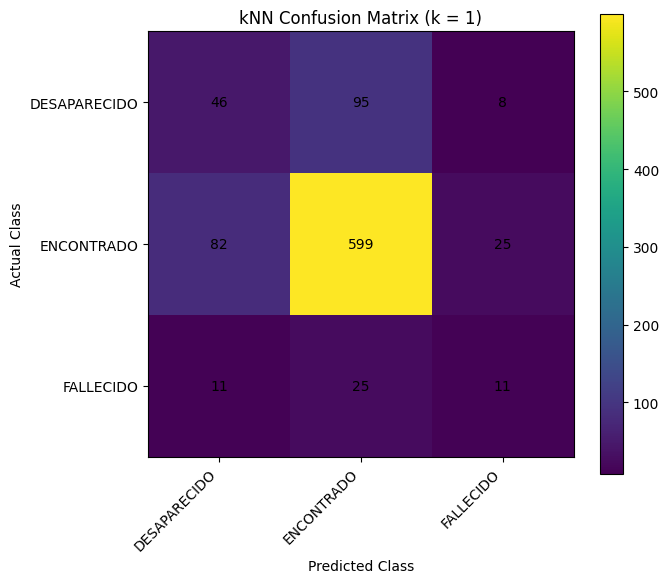

In [56]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    knn_confusion_matrix
)

ax.set_title(
    f"kNN Confusion Matrix (k = {best_k})"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks(
    np.arange(len(knn_labels))
)

ax.set_yticks(
    np.arange(len(knn_labels))
)

ax.set_xticklabels(
    knn_labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    knn_labels
)

for i in range(len(knn_labels)):

    for j in range(len(knn_labels)):

        ax.text(
            j,
            i,
            knn_confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.show()

In [57]:
final_model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            f"kNN (k={best_k})"
        ],

        "Accuracy": [
            logistic_accuracy,
            rf_accuracy,
            knn_accuracy
        ],

        "Macro Precision": [
            logistic_precision,
            rf_precision,
            knn_precision
        ],

        "Macro Recall": [
            logistic_recall,
            rf_recall,
            knn_recall
        ],

        "Macro F1": [
            logistic_f1,
            rf_f1,
            knn_f1
        ]
    }
)

final_model_comparison = (
    final_model_comparison
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.7661,0.5580,0.5041,0.5175
1,kNN (k=1),0.7273,0.4713,0.4637,0.4673
2,Logistic Regression,0.5499,0.4440,0.5532,0.4248


In [58]:
final_best_model_name = final_model_comparison.loc[
    0,
    "Model"
]

final_best_accuracy = final_model_comparison.loc[
    0,
    "Accuracy"
]

final_best_f1 = final_model_comparison.loc[
    0,
    "Macro F1"
]

print(
    "Best overall model:",
    final_best_model_name
)

print(
    "Accuracy:",
    round(final_best_accuracy, 4)
)

print(
    "Macro F1-score:",
    round(final_best_f1, 4)
)

Best overall model: Random Forest
Accuracy: 0.7661
Macro F1-score: 0.5175


## 34. Prediction of a New Case

After comparing the classification models, Random Forest was selected as the best overall model because it obtained the highest Macro F1-score.

The final model will now be used to classify a new hypothetical observation that was not part of either the training or testing datasets.

In [59]:
final_model = random_forest_model

new_case = {}

for column in X_train.columns:

    if pd.api.types.is_numeric_dtype(X_train[column]):

        new_case[column] = X_train[column].median()

    else:

        mode_values = X_train[column].mode(dropna=True)

        if len(mode_values) > 0:
            new_case[column] = mode_values.iloc[0]
        else:
            new_case[column] = "UNKNOWN"


new_case = pd.DataFrame(
    [new_case]
)


# Modify some values to create a new hypothetical observation

if "edad" in new_case.columns:
    new_case.loc[0, "edad"] = 28

if "mes_desaparicion" in new_case.columns:
    new_case.loc[0, "mes_desaparicion"] = 6

if "dia_semana_desaparicion" in new_case.columns:
    new_case.loc[0, "dia_semana_desaparicion"] = 2

if "dias_hasta_denuncia" in new_case.columns:
    new_case.loc[0, "dias_hasta_denuncia"] = 1

if "dias_hasta_conocimiento" in new_case.columns:
    new_case.loc[0, "dias_hasta_conocimiento"] = 1

# Slightly modify latitude to help ensure that this is a new observation
if "latitud" in new_case.columns:
    new_case.loc[0, "latitud"] = (
        float(new_case.loc[0, "latitud"]) + 0.0001
    )


print("New hypothetical case:")

display(
    new_case.T.rename(
        columns={0: "Value"}
    )
)

New hypothetical case:


,Value
zona,ZONA 9
provincia,GUAYAS
canton,QUITO
latitud,-1.274496
longitud,-79.120379
sexo,MUJER
nacionalidad,ECUADOR
edad,28.0
etnia,MESTIZO/A
mes_desaparicion,6.0


In [60]:
is_in_training = (
    X_train
    .eq(new_case.iloc[0])
    .all(axis=1)
    .any()
)

is_in_testing = (
    X_test
    .eq(new_case.iloc[0])
    .all(axis=1)
    .any()
)

print("Observation exists in training set:", is_in_training)
print("Observation exists in testing set:", is_in_testing)

Observation exists in training set: False
Observation exists in testing set: False


In [61]:
new_prediction = final_model.predict(
    new_case
)

print(
    "Predicted class:",
    new_prediction[0]
)

Predicted class: ENCONTRADO


In [62]:
new_probabilities = final_model.predict_proba(
    new_case
)[0]

classes = final_model.classes_

probability_table = pd.DataFrame(
    {
        "Class": classes,
        "Probability": new_probabilities
    }
)

probability_table["Probability (%)"] = (
    probability_table["Probability"]
    .mul(100)
    .round(2)
)

probability_table = probability_table.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

display(probability_table)

,Class,Probability,Probability (%)
0,ENCONTRADO,0.57,57.0
1,DESAPARECIDO,0.35,35.0
2,FALLECIDO,0.08,8.0


## 38. Final Model Results

The final performance of the evaluated classification algorithms is summarized below.

In [63]:
final_results = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            f"kNN (k={best_k})",
            "Logistic Regression"
        ],

        "Accuracy": [
            rf_accuracy,
            knn_accuracy,
            logistic_accuracy
        ],

        "Macro Precision": [
            rf_precision,
            knn_precision,
            logistic_precision
        ],

        "Macro Recall": [
            rf_recall,
            knn_recall,
            logistic_recall
        ],

        "Macro F1": [
            rf_f1,
            knn_f1,
            logistic_f1
        ]
    }
)

final_results = final_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    final_results.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.7661,0.5580,0.5041,0.5175
1,kNN (k=1),0.7273,0.4713,0.4637,0.4673
2,Logistic Regression,0.5499,0.4440,0.5532,0.4248
